In [12]:
import pandas as pd
import numpy as np
import json

In [13]:
# Load the data
df = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df = df.sort_values(by='Age at S1K')


# Drop Unnamed: 0 column
df = df.drop(columns=['Unnamed: 0'])

# Reset index
df = df.reset_index(drop=True)
print(df)

    Age at BMT  Age at S1K  Days postBMT  Lamis ID      total_FM     fd_FM  \
0           41          59            18    848686  2.512505e+07  0.225565   
1           41          62            21    848689  2.088744e+07  0.002681   
2           41          69            28    848688  2.856593e+07  0.174667   
3           41          76            35    848701  2.082702e+07  0.197221   
4           41          88            14    848687  2.440681e+07  0.013667   
5           74          88            14    832634  2.247009e+07  0.016125   
6           74          92            18    832635  2.489367e+07  0.001095   
7           74          95            21    832636  2.737972e+07  0.273494   
8           74         102            28    832637  2.432153e+07  0.266730   
9           74         109            35    832653  2.986468e+07  0.406642   
10          41         119            54    882098  2.572667e+07  0.339416   
11          41         123            82    848700  2.849576e+07

In [14]:
# Create 5 csv files based on each precursor and MZB cells 

precursors = ['T2_MZP', 'FM', 'MZ', 'T2']
for precursor in precursors:
    precursor_df = df[['Lamis ID', 'Age at S1K', 'Age at BMT', 'Days postBMT', f'total_{precursor}', f'fd_{precursor}', f'Nfd_{precursor}',f'frac_Ki67+_{precursor}_donor', f'frac_Ki67+_{precursor}_host']]
    precursor_df.to_csv(f'/home/apoorva/Desktop/work/MZ_analysis/data/{precursor}_data.csv', index=False)       


precursor_T1 = df[['Lamis ID', 'Age at S1K', 'Age at BMT', 'Days postBMT', 'total_T1_AA4.1+', 'fd_T1_AA4.1+', 'frac_Ki67+_T1_AA4.1+_donor', 'frac_Ki67+_T1_AA4.1+_host']]
precursor_T1.to_csv(f'/home/apoorva/Desktop/work/MZ_analysis/data/T1_data.csv', index=False)


First create a vector of time points to feed into the ode solver -- `solve_time`. This vector cannot have repeated timepoints (duplicates). <br>
So to map `solve_time` to the data timepoints i.e. `data_time` we create an index map. <br>
We also need a `age_at_bmt` vector to use with ode solver and `solve_time`.

In [15]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df['agebin'] = pd.cut(df['Age at BMT'], bins=[0, 70, 140], labels=['<10 weeks', '>10 weeks'])
#Drop last row
df = df.iloc[:-2]
print(df)

    Age at BMT  Age at S1K  Days postBMT  Lamis ID      total_FM     fd_FM  \
0           41          59            18    848686  2.512505e+07  0.225565   
1           41          62            21    848689  2.088744e+07  0.002681   
2           41          69            28    848688  2.856593e+07  0.174667   
3           41          76            35    848701  2.082702e+07  0.197221   
4           41          88            14    848687  2.440681e+07  0.013667   
5           74          88            14    832634  2.247009e+07  0.016125   
6           74          92            18    832635  2.489367e+07  0.001095   
7           74          95            21    832636  2.737972e+07  0.273494   
8           74         102            28    832637  2.432153e+07  0.266730   
9           74         109            35    832653  2.986468e+07  0.406642   
10          41         119            54    882098  2.572667e+07  0.339416   
11          41         123            82    848700  2.849576e+07

In [16]:
# Group the data by agebin and calculate mode and median for 'Age at BMT'
df_mode = df.groupby('agebin')['Age at BMT'].agg([lambda x: x.mode()[0], 'median', 'mean']).reset_index()
df_mode.columns = ['agebin', 'mode', 'median', 'mean']
print(df_mode)

      agebin  mode  median       mean
0  <10 weeks    41    41.0  47.333333
1  >10 weeks    74    74.0  81.125000


/tmp/ipykernel_445121/2145387024.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mode = df.groupby('agebin')['Age at BMT'].agg([lambda x: x.mode()[0], 'median', 'mean']).reset_index()


In [17]:
# data time points
data_time = df['Age at S1K'].values

# Create a dataframe with unique age at S1K values
dfunique = df.drop_duplicates(subset='Age at S1K', keep='first')
dfunique = dfunique.sort_values(by='Age at S1K')
dfunique = dfunique.reset_index(drop=True)

# unique time points in data
solve_time = dfunique['Age at S1K'].values
solve_ageatbmt = dfunique['Age at BMT'].values

# create index map of data time to solve time for Nfd
time_index_map = np.zeros(len(data_time), dtype=int)
for i, t in enumerate(solve_time):
    time_index_map[data_time == t] = i+1


#time sequence for predictions specific to agebins within the data
time_pred1_solve= np.array(np.arange(52, 750, 1))
time_pred2_solve= np.array(np.arange(88, 750, 1))
time_pred1_bmt = 41.0
time_pred2_bmt= 74.0



Mean Total MZ: 2642450.14626146
Std Total MZ: 724150.1166034268
Variance Total MZ: 26.98550798650017


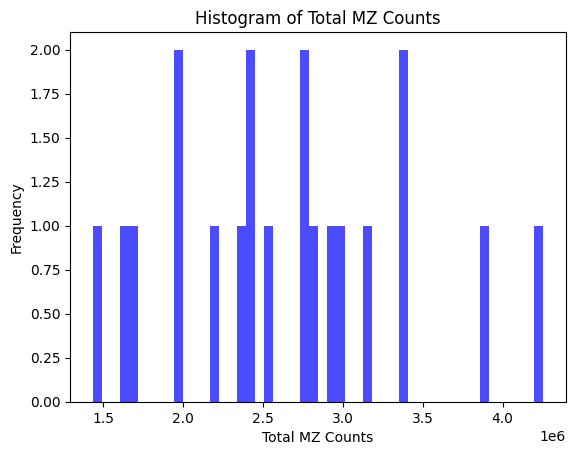

In [18]:
# Find mean and std for total mz counts
mean_mz = df['total_MZ'].mean()
print("Mean Total MZ:", mean_mz)
std_mz = np.std(df['total_MZ'])
print("Std Total MZ:", std_mz)

#Vaiance of total mz counts
var_mz = np.var(df['total_MZ'])
print("Variance Total MZ:", np.log(var_mz))

#Plot histogram of total mz counts
import matplotlib.pyplot as plt
plt.hist(df['total_MZ'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Total MZ Counts')
plt.xlabel('Total MZ Counts')
plt.ylabel('Frequency')
# plt.xscale('log')
plt.show()




In [19]:
# Creating a list to use as an input in Stan model
data={"numobs" : len(df['Age at S1K']),  # Number of donor fraction observations
      "numsolve" : len(solve_time),  # Number of unique time points in the data
      "data_time" : data_time,
      "time_index_map" : time_index_map,
      "solve_time" : solve_time,
      "solve_ageatBMT" : solve_ageatbmt, # Age at BMT for the solve time points
      "totalMZ" : np.array(df['total_MZ']),
      "Nfd" : np.array(df['Nfd_MZ']),
      "dayspbmt" : np.array(df['Days postBMT']),
      "ageatbmt" : np.array(df['Age at BMT']),
      "ki_donor" : np.array(df['frac_Ki67+_MZ_donor']),
      "ki_host" : np.array(df['frac_Ki67+_MZ_host']),
      "time_pred1_solve" : time_pred1_solve,
      "time_pred2_solve" : time_pred2_solve,

      "time_pred1_bmt" : time_pred1_bmt,
      "time_pred2_bmt" : time_pred2_bmt,
    
      "numpred1" : len(time_pred1_solve),
      "numpred2" : len(time_pred2_solve),

      }

In [20]:
# Export data to JSON
def numpy_array_encoder(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert numpy array to a list
    raise TypeError("Object of type {} is not JSON serializable".format(type(obj)))

# Serialize dictionary to JSON using custom encoder function
json_string = json.dumps(data, default=numpy_array_encoder)

file_path= "/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_sensitivityanalysis.json"
with open(file_path, "w") as json_file:  json_file.write(json_string)

print("Data saved to", file_path)

Data saved to /home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_sensitivityanalysis.json
